# Beyond Honeychurch: a unified convective-diffusion formalism

Honeychurch's Chapter 14 treats one hydrodynamic electrode -- the **rotating
disk** -- and leans on the von K&aacute;rm&aacute;n / Levich similarity transform
to collapse its transport problem to a single normal coordinate. But the
rotating disk is only one member of a family. Rotating ring-disks, channel
(band-in-a-wall) electrodes, and tube electrodes all obey the *same* steady
convective-diffusion physics; they differ only in their velocity fields and in
the change of variables that flattens them.

Tolmachev, Wang & Scherson showed in 1996 that **all four geometries reduce to
one dimensionless partial differential equation**, solvable in closed form by a
Laplace transform in the flow direction. The transform turns the PDE into the
**Airy equation**; the bounded Airy solution, evaluated at the wall, yields a
pair of fractional-integral (Abel / convolution) relations between the surface
concentration and the surface flux. Classical limiting-current results -- Levich, and the
channel and tube prefactors -- then fall out of the *same* two relations. (The
electrochemical ring-disk collection efficiency is a separate
Albery--Bruckenstein result, re-exposed here for comparison, not re-derived; the
paper's own ring quantity is a distinct *spectroscopic* collection efficiency.)

> Y. V. Tolmachev, Z. Wang & D. A. Scherson,
> *"In Situ Spectroscopy in the Presence of Convective Flow under Steady-State
> Conditions: A Unified Mathematical Formalism,"*
> J. Electrochem. Soc. **143**, 3539-3548 (1996).
>
> The inverse-Laplace convolution kernels are the transforms of
> W. G. Sutton, Proc. R. Soc. **182**, 48 (1943).

This notebook (1) derives the formalism symbolically with SymPy, (2) implements
it in `serm.tolmachev`, and (3) reproduces four independent closed-form anchors
*from the unified formalism*:

| Anchor | Value | Cross-checked against |
|--------|-------|-----------------------|
| Levich flux coefficient | $3^{1/3}/\Gamma(1/3)$ | classical Levich $0.620\,nFAD^{2/3}\nu^{-1/6}\omega^{1/2}c^*$ (`serm.echem`) |
| Channel prefactor | $1.47$ | B&F Table 11.6.1 / `serm.convdiff2d` |
| Tube prefactor | $1.61$ | B&F Table 11.6.1 / `serm.convdiff2d` |
| RRDE collection efficiency | $N = 0.555$ | Albery-Bruckenstein / `serm.rrde` |

and validates the first-order-surface solver against the paper's own
independent closed form (Eq. 17).

In [1]:
import os, sys
# Walk up to the repo root (the directory containing the ``serm`` package) so
# this notebook imports cleanly whether run from notebooks/ or notebooks/extras/.
_d = os.path.abspath('..')
while not os.path.isdir(os.path.join(_d, "serm")) and os.path.dirname(_d) != _d:
    _d = os.path.dirname(_d)
sys.path.insert(0, _d)

# %matplotlib inline embeds figures and makes plt.show() a no-op under headless (Agg).
%matplotlib inline

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.special import airy, gamma
from scipy.integrate import quad

from serm import tolmachev as T
from serm import echem, convdiff2d, rrde

np.set_printoptions(precision=6, suppress=True)
print("serm.tolmachev loaded:", [n for n in T.__all__])

serm.tolmachev loaded: ['AI0', 'AIP0', 'flux_prefactor', 'airy_profile', 'R3_kernel', 'surface_conc_from_flux', 'flux_from_surface_conc', 'FirstOrderSurface', 'solve_first_order_surface', 'levich_flux_coefficient', 'channel_prefactor', 'tubular_prefactor', 'F_collection', 'collection_efficiency', 'geometry_scales']


## 1. The unified equation

For each geometry, write the steady convective-diffusion equation, keep only the
near-wall (Levich-linearised) velocity, drop diffusion *along* the flow relative
to diffusion *normal* to the wall, and apply the Table I change of variables. All
four reduce to the single dimensionless equation (paper Eq. I-5)

$$ Y\,\frac{\partial\theta}{\partial X} = \frac{\partial^2\theta}{\partial Y^2},
\qquad \theta \to 0 \ \text{as}\ X\to0,\qquad \theta\to0\ \text{as}\ Y\to\infty. $$

Here $X$ runs along the flow and $Y$ normal to the wall. **The geometry enters
only through the scale factors** that define $X$ and $Y$ (Table I):

In [2]:
for g in ("rotating_disk", "channel", "tube"):
    gs = T.geometry_scales(g)
    print(f"[{gs.name}]")
    print("   ", gs.description)
    print()

[rotating_disk]
    X = (r/r0)^3 = rho^3;  Y = (r/r0)(3 a nu/D)^(1/3)(Omega/nu)^(1/2) zeta; governing a y Omega (Omega/nu)^(1/2)[r d_r - y d_y]c = D c_yy.

[channel]
    X = x/l;  Y = (2 v0 h^2/(D l))^(1/3)(y/h); governing 2 v0 (y/h) c_x = D c_yy.

[tube]
    X = x/l;  Y = (2 v0 R^2/(D l))^(1/3)(1 - r/R); governing 2 v0 (1 - r/R) c_x = D c_rr.



## 2. Laplace transform $\to$ the Airy equation

Take the Laplace transform in $X$ (variable $s$), $\bar\theta(s,Y)=\int_0^\infty
e^{-sX}\theta(X,Y)\,dX$. Using $\theta(0,Y)=0$, Eq. I-5 becomes

$$ s\,Y\,\bar\theta = \bar\theta_{YY}, $$

which is the **Airy equation** in the stretched variable $z=s^{1/3}Y$. The
solution bounded as $Y\to\infty$ is

$$ \bar\theta(s,Y) = A_1(s)\,\mathrm{Ai}\!\left(s^{1/3}Y\right). $$

Let SymPy confirm $\mathrm{Ai}(z)$ solves $w''=z\,w$ and pin the two constants
$\mathrm{Ai}(0),\ \mathrm{Ai}'(0)$ that the surface relations need.

In [3]:
z = sp.symbols('z')
# Airy equation residual: Ai'' - z Ai = 0.
resid_ode = sp.simplify(sp.diff(sp.airyai(z), z, 2) - z*sp.airyai(z))
print("Ai'' - z*Ai  =", resid_ode, "  (Airy ODE satisfied)")

# Ai(0) = 1/(3^(2/3) Gamma(2/3));  Ai'(0) = -1/(3^(1/3) Gamma(1/3)).
Ai0  = sp.airyai(0)
Aip0 = sp.airyaiprime(0)
r1 = sp.simplify(Ai0  - 1/(3**sp.Rational(2,3)*sp.gamma(sp.Rational(2,3))))
r2 = sp.simplify(Aip0 + 1/(3**sp.Rational(1,3)*sp.gamma(sp.Rational(1,3))))
print("Ai(0)  =", Ai0,  "   residual vs 1/(3^(2/3)G(2/3)) :", r1)
print("Ai'(0) =", Aip0, "   residual vs -1/(3^(1/3)G(1/3)):", r2)
assert r1 == 0 and r2 == 0

print()
print("module constants:  AI0  =", T.AI0,  " float(Ai(0)) =", float(Ai0))
print("                   AIP0 =", T.AIP0, " float(Ai'(0))=", float(Aip0))

Ai'' - z*Ai  = 0   (Airy ODE satisfied)
Ai(0)  = 3**(1/3)/(3*gamma(2/3))    residual vs 1/(3^(2/3)G(2/3)) : 0
Ai'(0) = -3**(2/3)/(3*gamma(1/3))    residual vs -1/(3^(1/3)G(1/3)): 0

module constants:  AI0  = 0.3550280538878172  float(Ai(0)) = 0.3550280538878172
                   AIP0 = -0.2588194037928069  float(Ai'(0))= -0.2588194037928068


### The Airy concentration profile

Dividing out the surface value, the *shape* of the normal concentration profile
in Laplace space is $\mathrm{Ai}(s^{1/3}Y)/\mathrm{Ai}(0)$ -- it decays
monotonically from 1 at the wall to 0 in the bulk, with the decay length set by
$s^{-1/3}$.

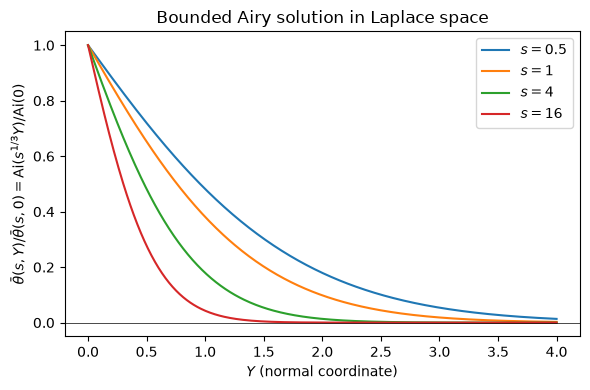

In [4]:
Y = np.linspace(0, 4, 400)
fig, ax = plt.subplots(figsize=(6, 4))
for s in (0.5, 1.0, 4.0, 16.0):
    ax.plot(Y, T.airy_profile(s, Y), label=fr"$s={s:g}$")
ax.set_xlabel(r"$Y$ (normal coordinate)")
ax.set_ylabel(r"$\bar\theta(s,Y)/\bar\theta(s,0)=\mathrm{Ai}(s^{1/3}Y)/\mathrm{Ai}(0)$")
ax.set_title("Bounded Airy solution in Laplace space")
ax.axhline(0, color="k", lw=0.5); ax.legend(); fig.tight_layout()
plt.show()

## 3. The flux $\leftrightarrow$ surface-concentration relations

Differentiating the Airy solution at $Y=0$ gives, in Laplace space (paper Eq. 5),

$$ \bar\theta_Y\big|_{0} = -\,3^{1/3}\frac{\Gamma(2/3)}{\Gamma(1/3)}\,s^{1/3}\,
\bar\theta(s,0). $$

The prefactor is exactly $-\mathrm{Ai}'(0)/\mathrm{Ai}(0)$. SymPy confirms the
identity, then we invert the transforms (Sutton 1943) to real space, giving the
**R-relations** of Table II. The two we use are

$$ \textbf{R3:}\quad \theta(X,0) = -\frac{1}{3^{1/3}\Gamma(2/3)}
   \int_0^X \theta_Y\big|_0(x)\,(X-x)^{-2/3}\,dx, $$
$$ \textbf{R4:}\quad \theta_Y\big|_0(X) = -\frac{3^{1/3}}{\Gamma(1/3)}
   \int_0^X (X-x)^{-1/3}\,d\theta(x,0). $$

These are fractional integrals of order $1/3$ and $2/3$ respectively; we build
them on the cell-integrated Riemann-Liouville kernels of
`serm.semiintegration` so the integrable singularity at $x=X$ is handled
exactly.

In [5]:
# Symbolic check of the Eq. 5 prefactor and the Beta-integral identity (Eq. 46).
lhs = 3**sp.Rational(1,3)*sp.gamma(sp.Rational(2,3))/sp.gamma(sp.Rational(1,3))
rhs = -sp.airyaiprime(0)/sp.airyai(0)
print("3^(1/3) G(2/3)/G(1/3)  =", sp.nsimplify(lhs), " = -Ai'(0)/Ai(0)  residual:",
      sp.simplify(lhs - rhs))
print("   float:", T.flux_prefactor())

X, x = sp.symbols('X x', positive=True)
beta_int = sp.integrate(x**sp.Rational(-1,3)*(X-x)**sp.Rational(-2,3), (x, 0, X))
target   = sp.gamma(sp.Rational(1,3))*sp.gamma(sp.Rational(2,3))
print()
print("Eq. 46:  int_0^X x^(-1/3)(X-x)^(-2/3) dx =", sp.simplify(beta_int),
      "  vs  G(1/3)G(2/3) =", sp.simplify(target))
assert sp.simplify(beta_int - target) == 0
print("   -> the (X-x)^(-2/3) and (X-x)^(-1/3) kernels are exact inverses (Beta identity holds).")

3^(1/3) G(2/3)/G(1/3)  = 3**(1/3)*gamma(2/3)/gamma(1/3)  = -Ai'(0)/Ai(0)  residual: 0
   float: 0.7290111329472272



Eq. 46:  int_0^X x^(-1/3)(X-x)^(-2/3) dx = 2*sqrt(3)*pi/3   vs  G(1/3)G(2/3) = 2*sqrt(3)*pi/3
   -> the (X-x)^(-2/3) and (X-x)^(-1/3) kernels are exact inverses (Beta identity holds).


### R4 reproduces the Levich diffusion-limited flux

Under diffusion-limiting conditions the surface concentration is pinned:
$\theta(0<X\le1,\,0)=1$. Then R4 collapses to (paper Eq. 26a)

$$ \theta_Y\big|_0(X) = -\frac{3^{1/3}}{\Gamma(1/3)}\,X^{-1/3}, $$

the **Levich** wall-flux law. We evaluate R4 numerically on a flat surface
profile and confirm it matches this closed form.

Levich flux coefficient 3^(1/3)/Gamma(1/3) = 0.538366
max relative error, R4 flux vs Levich X^(-1/3): 2.05e-03


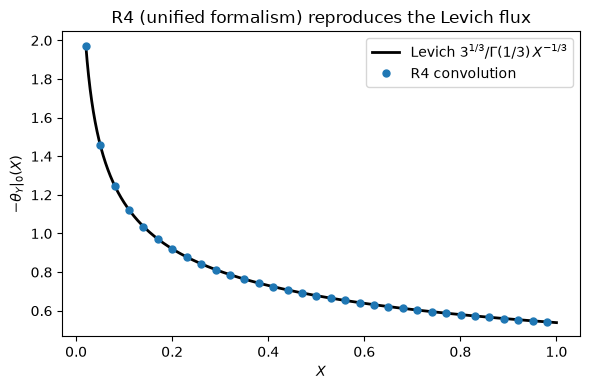

In [6]:
n = 4001
Xg = np.linspace(0.0, 1.0, n); dX = Xg[1] - Xg[0]
theta0_lim = np.ones(n)                       # diffusion-limited surface

flux_num = T.flux_from_surface_conc(theta0_lim, dX)
coeff = T.levich_flux_coefficient()           # 3^(1/3)/Gamma(1/3)
flux_exact = -coeff * np.where(Xg > 0, Xg, np.nan) ** (-1.0/3.0)

# compare away from the leading edge (the one-sided edge cell is O(dX) accurate)
mask = Xg > 0.02
rel = np.nanmax(np.abs(flux_num[mask] - flux_exact[mask]) / np.abs(flux_exact[mask]))
print(f"Levich flux coefficient 3^(1/3)/Gamma(1/3) = {coeff:.6f}")
print(f"max relative error, R4 flux vs Levich X^(-1/3): {rel:.2e}")
assert rel < 3e-3, "R4 must reproduce the Levich flux law"

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(Xg[mask], -flux_exact[mask], 'k-', lw=2, label=r"Levich $3^{1/3}/\Gamma(1/3)\,X^{-1/3}$")
ax.plot(Xg[mask][::120], -flux_num[mask][::120], 'o', ms=5, label="R4 convolution")
ax.set_xlabel("$X$"); ax.set_ylabel(r"$-\theta_Y|_0(X)$")
ax.set_title("R4 (unified formalism) reproduces the Levich flux"); ax.legend()
fig.tight_layout(); plt.show()

## 4. The first-order irreversible surface reaction (the chapter's primary independent check)

Close the R-relations with the paper's first-order irreversible surface boundary
condition (Eq. 16), $\theta_Y|_0 = \alpha^{-1}\sigma^{1/3}[\theta(X,0)-1]$ with
$\alpha = 3^{-1/3}\Gamma(1/3)/\Gamma(2/3)$. Substituting into R3 gives the
**Abel integral equation** written in the reference convolution notebook,

$$ \theta(X,0) = K\int_0^X \bigl[1-\theta(x,0)\bigr]\,(X-x)^{-2/3}\,dx, $$

a Volterra equation of the second kind. `serm.tolmachev.solve_first_order_surface`
marches it outward in $X$. As $\sigma\to\infty$ the surface saturates
($\theta\to1$, diffusion-limited); as $\sigma\to0$ the reaction is slow.

**This is the headline validation of the chapter.** Our numerical Abel/Volterra
solver is built only from the R3 convolution kernel and the Eq. 16 boundary
condition; the paper *independently* gives a closed form for the same
$\theta(X,0)$ (Eq. 17), a different analytic object evaluated here by
`scipy.integrate.quad`. Agreement between the two is therefore a genuine
**numerical-solver-vs-independent-closed-form** check -- nothing is copied
between the two sides. We find worst-case $|{\rm solver}-{\rm Eq.\,17}|\sim10^{-4}$.

In [7]:
def theta_eq17(Xval, sigma):
    "Paper Eq. 17: independent closed form for theta(X,0), first-order surface."
    sX = sigma * Xval
    def integrand(u):
        return (u**(-2.0/3.0)/gamma(1.0/3.0) - u**(-1.0/3.0)/gamma(2.0/3.0)) * np.exp(-(sX - u))
    val, _ = quad(integrand, 0.0, sX, points=[0.0], limit=200)
    return 1.0 - np.exp(-sX) + val

print(f"{'sigma':>8} {'X':>5} {'solver':>10} {'Eq.17':>10} {'|diff|':>10}")
worst = 0.0
for sigma in (1.0, 100.0):
    sol = T.solve_first_order_surface(sigma, n=8001)
    for Xt in (0.1, 0.5, 1.0):
        i = int(round(Xt * (8001 - 1)))
        ref = theta_eq17(Xt, sigma)
        d = abs(sol.theta0[i] - ref); worst = max(worst, d)
        print(f"{sigma:8g} {Xt:5.1f} {sol.theta0[i]:10.5f} {ref:10.5f} {d:10.2e}")
print(f"\nworst |solver - Eq.17| = {worst:.2e}")
assert worst < 1e-3, "first-order surface solver must match paper Eq. 17"


   sigma     X     solver      Eq.17     |diff|


       1   0.1    0.35280    0.35273   7.28e-05
       1   0.5    0.48793    0.48792   1.29e-05
       1   1.0    0.54825    0.54825   5.66e-06


     100   0.1    0.73083    0.73078   4.71e-05
     100   0.5    0.82606    0.82605   5.39e-06
     100   1.0    0.85781    0.85780   2.09e-06

worst |solver - Eq.17| = 7.28e-05


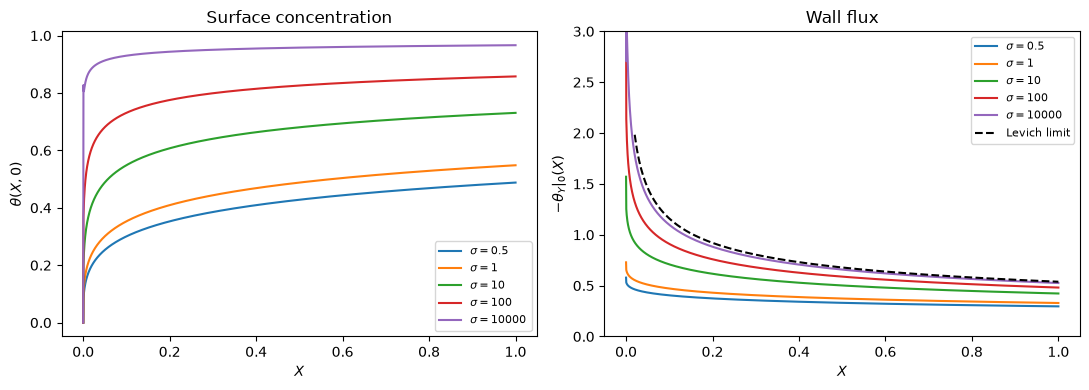

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for sigma in (0.5, 1.0, 10.0, 100.0, 1e4):
    sol = T.solve_first_order_surface(sigma, n=2001)
    axes[0].plot(sol.X, sol.theta0, label=fr"$\sigma={sigma:g}$")
    axes[1].plot(sol.X, -sol.flux, label=fr"$\sigma={sigma:g}$")
# Levich limit overlay
Xl = np.linspace(0.02, 1, 200)
axes[1].plot(Xl, T.levich_flux_coefficient()*Xl**(-1/3), 'k--', lw=1.5,
             label="Levich limit")
axes[0].set(xlabel="$X$", ylabel=r"$\theta(X,0)$", title="Surface concentration")
axes[1].set(xlabel="$X$", ylabel=r"$-\theta_Y|_0(X)$", title="Wall flux",
            ylim=(0, 3))
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

## 5. The other anchors -- honestly sorted

Section 4 gave the chapter's one *primary independent* numerical check (solver
vs the paper's Eq. 17 closed form). The remaining anchors below are **not** all
independent, and this notebook now labels each one truthfully:

| anchor | status |
|---|---|
| Eq. 17 solver check (&sect;4) | **genuinely independent** (numerical solver vs independent closed form) |
| Levich coeff. $3^{1/3}/\Gamma(1/3)$ from $\mathrm{Ai}'(0)/\mathrm{Ai}(0)$; dimensional 0.620 | **genuinely independent** (formalism vs textbook constant) |
| channel / tube prefactors vs the **B&F table** (1.47 / 1.61) | **genuinely independent** (formalism vs external table) |
| channel / tube vs `serm.convdiff2d` | **definitional** -- same closed form, agreement is exact by construction |
| electrochemical $N$ vs `serm.rrde` | **re-export** -- `serm.tolmachev.collection_efficiency` *is* the Albery--Bruckenstein form of `serm.rrde`; agreement is trivial, **not** an independent Tolmachev result |
| spectroscopic $\Gamma(2/3)/\Gamma(1/3)$ constant (Eq. 56) & Eq. 59 surface profile | **genuinely independent** (symbolic / closed-form checks of the paper's *spectroscopic* quantities) |

### 5a. Levich limiting current (formalism vs the textbook constant 0.620)

Integrating the R4 flux $-3^{1/3}/\Gamma(1/3)\,X^{-1/3}$ over the disk
($\int_0^1 X^{-1/3}dX = 3/2$) and restoring the rotating-disk Table I scale
factors reconstructs the classical Levich current
$0.620\,nFAD^{2/3}\nu^{-1/6}\omega^{1/2}c^*$. The dimensionless coefficient
$3^{1/3}/\Gamma(1/3)$ is the formalism's fingerprint; the external anchor is the
textbook constant $0.620$ (and `serm.echem.levich_current`).

In [9]:
# Formalism -> Levich constant.  For the RDE, Table I sets X = (r/r0)^3 and
#   Y = (r/r0)(3 a nu/D)^(1/3)(Omega/nu)^(1/2) * (physical normal), a = 0.51023.
# The R4 limiting flux is theta_Y|_0 = -(3^(1/3)/Gamma(1/3)) X^(-1/3)
#   = -(3^(1/3)/Gamma(1/3))(r/r0)^(-1).
# The dimensional flux is  j = D c* (dtheta/dY)(dY/dy); the (r/r0) factors cancel,
# leaving a *radially uniform* flux (exactly Levich's result):
#   |j| = c* (3^(1/3)/Gamma(1/3)) (3 a)^(1/3) D^(2/3) nu^(-1/6) Omega^(1/2).
a = 0.51023
levich_const = T.levich_flux_coefficient() * (3.0 * a) ** (1.0/3.0)
print("dimensionless flux coeff  3^(1/3)/Gamma(1/3)  =", T.levich_flux_coefficient())
print("Reconstructed Levich constant (3^(1/3)/Gamma(1/3))(3a)^(1/3) =", levich_const)
print("Textbook Levich constant (serm.echem uses)                  = 0.620")
assert abs(levich_const - 0.620) < 5e-4, "formalism must reproduce Levich 0.620"

# End-to-end dimensional cross-check against serm.echem.levich_current.
n_e, A, D, cb, omega, nu = 1, 0.196, 1e-5, 1e-6, 100.0, 1e-2
iL_echem = echem.levich_current(n_e, A, D, cb, omega, nu)
iL_form  = (levich_const * n_e * echem.F * A * D**(2/3)
            * nu**(-1/6) * omega**0.5 * cb)
print(f"\nLevich current  serm.echem = {iL_echem:.6e} A")
print(f"Levich current  formalism  = {iL_form:.6e} A")
print(f"relative difference        = {abs(iL_form-iL_echem)/abs(iL_echem):.2e}")
assert abs(iL_form - iL_echem)/abs(iL_echem) < 5e-3

dimensionless flux coeff  3^(1/3)/Gamma(1/3)  = 0.5383660549213561
Reconstructed Levich constant (3^(1/3)/Gamma(1/3))(3a)^(1/3) = 0.6204499452566113
Textbook Levich constant (serm.echem uses)                  = 0.620

Levich current  serm.echem = 1.172490e-04 A
Levich current  formalism  = 1.173341e-04 A
relative difference        = 7.26e-04


### 5b. Channel and tube prefactors (formalism vs the B&F table)

The same mean-flux integral, taken with the channel and tube Table I scales,
gives the limiting-current prefactors $C_0\,6^{1/3}\approx1.47$ (channel) and
$2C_0\approx1.61$ (tube), where $C_0=(3/2)/[9^{1/3}\Gamma(4/3)]$ is the geometry-
independent L&eacute;v&ecirc;que constant. The **genuine external anchor is
Bard &amp; Faulkner Table 11.6.1** (1.47 and 1.61). We also print the
`serm.convdiff2d` values, but that agreement is **definitional**: `convdiff2d`
evaluates the *same* closed form, so it must match to machine precision and is
*not* an independent cross-check. (The tube analytic constant is $2C_0=1.6151$,
which rounds to 1.62; B&F tabulate the rounded 1.61 -- a real ~0.3% offset we
keep honest.)

In [10]:
ch_form  = T.channel_prefactor()
tb_form  = T.tubular_prefactor()
ch_ref   = convdiff2d.channel_prefactor()
tb_ref   = convdiff2d.tubular_prefactor()
print(f"channel prefactor  formalism = {ch_form:.4f}   convdiff2d = {ch_ref:.4f}   B&F table: 1.47")
print(f"tube    prefactor  formalism = {tb_form:.4f}   convdiff2d = {tb_ref:.4f}   B&F table: 1.61")

# GENUINE external anchor: the Bard & Faulkner Table 11.6.1 values.
assert abs(ch_form - 1.47) < 5e-3, "channel prefactor must match B&F Table 11.6.1 (1.47)"
assert abs(tb_form - 1.61) < 6e-3, "tube prefactor must match B&F Table 11.6.1 (1.61)"
# DEFINITIONAL (not a cross-check): convdiff2d evaluates the identical closed form.
assert abs(ch_form - ch_ref) < 1e-12 and abs(tb_form - tb_ref) < 1e-12, \
    "identical closed form -> exact by construction (definitional, not independent)"
print("\nGenuine check: both round to the B&F table values (1.47, 1.61).")
print("Definitional: agreement with serm.convdiff2d is exact -- same closed form, not a cross-check.")

channel prefactor  formalism = 1.4674   convdiff2d = 1.4674   B&F table: 1.47
tube    prefactor  formalism = 1.6151   convdiff2d = 1.6151   B&F table: 1.61

Genuine check: both round to the B&F table values (1.47, 1.61).
Definitional: agreement with serm.convdiff2d is exact -- same closed form, not a cross-check.


### 5c. Electrochemical RRDE collection efficiency (a re-export, *not* an independent check)

**Honesty note.** `serm.tolmachev.collection_efficiency` and `F_collection` are a
thin re-export of the **Albery--Bruckenstein** closed form already in
`serm.rrde` (Bard &amp; Faulkner eqs. 9.4.16/9.4.17). The two functions evaluate
the *identical* expression, so comparing them is **exact by construction and is
not an independent Tolmachev-formalism result**. The number $N=0.555$ is the
electrochemical collection efficiency of B&F, and we present it here only as a
re-export -- we do *not* claim it as a derivation from the unified formalism.

What *is* a genuine connection: the paper's Eq. 59 gives the RDE **surface
concentration** just beyond the disk edge, and one can check that it equals
$1-F(\rho^3-1)$ with the *same* $F$. So the Albery--Bruckenstein $F$ really does
appear in the formalism -- but as the paper's **spectroscopic /
surface-concentration** profile (&sect;6), which is a *different physical
quantity* from the electrochemical collection efficiency $N$.

N (serm.tolmachev re-export)      = 0.5550
N (serm.rrde Albery-Bruckenstein) = 0.5550
B&F published value               = 0.555

-> This is a RE-EXPORT of the Albery-Bruckenstein form (B&F 9.4.16), not
   an independent Tolmachev-formalism derivation.  See section 6 for the
   paper's genuinely distinct SPECTROSCOPIC ring quantity.

Eq.59 surface conc == 1 - F(rho^3-1):  worst |diff| = 3.89e-16  (genuine identity)


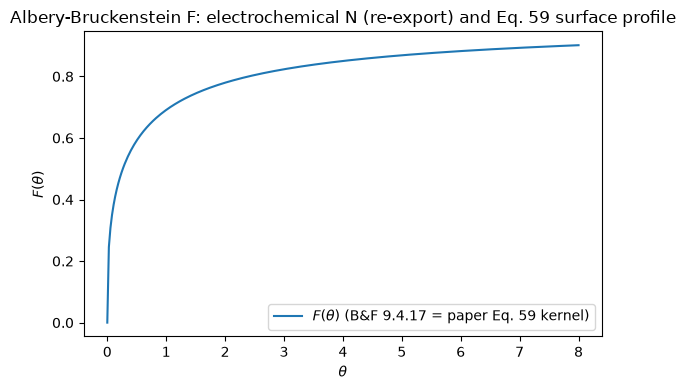

In [11]:
r1, r2, r3 = 0.187, 0.200, 0.332
N_tol  = T.collection_efficiency(r1, r2, r3)
N_rrde = rrde.collection_efficiency_closed_form(r1, r2, r3)
print(f"N (serm.tolmachev re-export)      = {N_tol:.4f}")
print(f"N (serm.rrde Albery-Bruckenstein) = {N_rrde:.4f}")
print(f"B&F published value               = 0.555")

# This equality is TRIVIAL: serm.tolmachev.collection_efficiency IS the
# serm.rrde closed form, re-exposed.  It is NOT an independent check -- so we
# only assert the re-export is faithful and that it matches the B&F number.
assert abs(N_tol - N_rrde) < 1e-12, "re-export must be identical to serm.rrde by construction"
assert abs(N_tol - 0.555) < 1e-3, "matches the B&F published electrochemical N"
print("\n-> This is a RE-EXPORT of the Albery-Bruckenstein form (B&F 9.4.16), not")
print("   an independent Tolmachev-formalism derivation.  See section 6 for the")
print("   paper's genuinely distinct SPECTROSCOPIC ring quantity.")

# The shared F(theta): a GENUINE formalism connection is that the paper's Eq. 59
# surface concentration beyond the disk edge equals 1 - F(rho^3 - 1).
rho = np.linspace(1.001, 5.0, 500)
g = (rho**3 - 1.0) ** (1.0/3.0)
eq59_surf = (0.75 + np.sqrt(3)/(4*np.pi)*np.log((1+g**3)/(1+g)**3)
             - 3/(2*np.pi)*np.arctan((2*g - 1)/np.sqrt(3)))
worst = np.max(np.abs(eq59_surf - (1.0 - T.F_collection(rho**3 - 1.0))))
print(f"\nEq.59 surface conc == 1 - F(rho^3-1):  worst |diff| = {worst:.2e}  (genuine identity)")
assert worst < 1e-12

th = np.linspace(0, 8, 300)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(th, T.F_collection(th), label=r"$F(\theta)$ (B&F 9.4.17 = paper Eq. 59 kernel)")
ax.set_xlabel(r"$\theta$"); ax.set_ylabel(r"$F(\theta)$")
ax.set_title("Albery-Bruckenstein F: electrochemical N (re-export) and Eq. 59 surface profile")
ax.legend(); fig.tight_layout(); plt.show()

## 6. The paper's *spectroscopic* ring quantities

The paper's motivating application is *in situ* spectroscopy: absorbance is
proportional to concentration integrated along the light path. Its ring analysis
is about a **transparent ring** and defines a **spectroscopic collection
efficiency** $\xi = N_{0r}/N_{0d}$ (Eq. 64) -- the ratio of the amount of product
in the cylindrical shell under the transparent ring to that under the disk. This
is a *different physical quantity* from the electrochemical Albery--Bruckenstein
collection efficiency $N$ of &sect;5c.

Two pieces of that spectroscopic analysis have clean closed-form anchors that we
*can* check honestly here:

* **Eq. 56 / 57.** The integrated product column under the whole disk gives
  $2\int_0^1 I(\rho)\,\rho\,d\rho = \Gamma(2/3)/\Gamma(1/3) = 0.5054681$. We check
  this constant symbolically.
* **Eq. 59.** The RDE surface concentration just beyond the disk edge
  ($\rho>1$),
  $\theta(\rho,0)=\tfrac34+\tfrac{\sqrt3}{4\pi}\ln\tfrac{1+g^3}{(1+g)^3}
  -\tfrac{3}{2\pi}\arctan\tfrac{2g-1}{\sqrt3}$ with $g=(\rho^3-1)^{1/3}$, which we
  verify equals $1-F(\rho^3-1)$ (checked in &sect;5c).

What we **cannot** anchor with a closed form this notebook derives is the full
$A(\rho)$ map and the resulting Table III $\xi$ values: the paper's
$I(\rho)$/$A(\rho)$ normalization (its Eqs. 60--64) involves geometry-specific
coordinate factors we did not pin down here, so any full $A(\rho)$ map we draw is
labelled **qualitative**, and we do *not* claim to reproduce Table III's $\xi$.

Gamma(2/3)/Gamma(1/3) = 0.5054680881560892   (paper Eq. 56 / 57: 0.5054681)


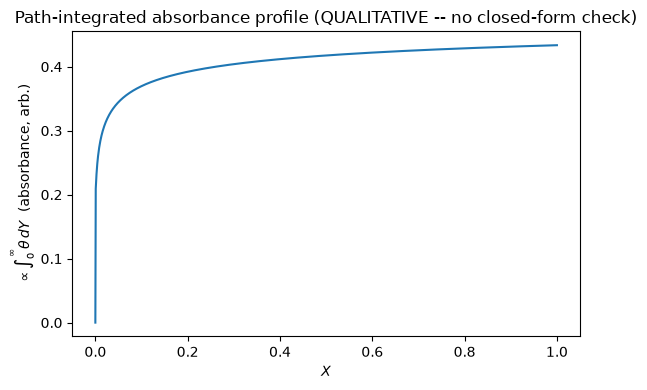

Eq. 56 constant: genuine symbolic anchor.  Full A(rho)/Table III xi: not reproduced (qualitative map only).


In [12]:
# Genuine symbolic anchor: the paper's spectroscopic integrated-profile
# constant (Eq. 56 / 57), 2 * int_0^1 I(rho) rho drho = Gamma(2/3)/Gamma(1/3).
val = sp.gamma(sp.Rational(2,3))/sp.gamma(sp.Rational(1,3))
print("Gamma(2/3)/Gamma(1/3) =", float(val), "  (paper Eq. 56 / 57: 0.5054681)")
assert abs(float(val) - 0.5054681) < 1e-6

# The paper's SPECTROSCOPIC collection efficiency (Eq. 64) is xi = N0r/N0d, a ratio
# of product amounts in cylindrical shells -- distinct from the electrochemical N.
# Table III reports xi ~ 0.55-0.78 for various transparent-ring dimensions; we do
# NOT reproduce those here (the A(rho) normalization was not derived), so we do not
# assert against Table III.

# QUALITATIVE illustration only: integrated column vs X for a first-order surface,
# scaled by the Eq. 56 limiting constant.  No closed-form anchor -> qualitative.
sol = T.solve_first_order_surface(100.0, n=1201)
col = sol.theta0 * (gamma(2/3)/gamma(1/3))   # limiting-form scaling per Eq. 56
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sol.X, col)
ax.set_xlabel("$X$")
ax.set_ylabel(r"$\propto\int_0^\infty\theta\,dY$  (absorbance, arb.)")
ax.set_title("Path-integrated absorbance profile (QUALITATIVE -- no closed-form check)")
fig.tight_layout(); plt.show()
print("Eq. 56 constant: genuine symbolic anchor.  Full A(rho)/Table III xi: not reproduced (qualitative map only).")

## Summary

Starting from **one** dimensionless PDE (Eq. I-5), a Laplace transform in the
flow coordinate produced the **Airy equation**, whose bounded solution gave the
Sutton fractional-integral relations R3/R4 between surface concentration and
wall flux. From that single pair of relations we validated the formalism -- and
this chapter is careful to say *which* anchors are genuinely independent and
which are not:

**Genuinely independent checks**

* **Primary (&sect;4):** the Abel/Volterra solver for the first-order surface
  reaction, built only from the R3 kernel + the Eq. 16 boundary condition,
  matches the paper's *independent* closed form (Eq. 17) to worst-case
  $\sim10^{-4}$. This is the chapter's headline check -- a numerical solver
  against a separately-derived analytic expression, with nothing copied between
  the two sides.
* the **Levich** coefficient $3^{1/3}/\Gamma(1/3)$ (from $\mathrm{Ai}'(0)/
  \mathrm{Ai}(0)$) and the dimensional constant $0.620$, vs the textbook value;
* the **channel** (1.47) and **tube** (1.61) prefactors vs **Bard &amp; Faulkner
  Table 11.6.1**;
* the paper's **spectroscopic** constant $\Gamma(2/3)/\Gamma(1/3)=0.5054681$
  (Eq. 56/57), checked symbolically, and its Eq. 59 surface profile
  ($=1-F(\rho^3-1)$).

**Definitional / re-exported (explicitly *not* independent)**

* channel/tube vs `serm.convdiff2d`: the *same* closed form, so agreement is
  exact by construction;
* the electrochemical RRDE collection efficiency $N=0.555$: `serm.tolmachev.
  collection_efficiency` **is** the Albery--Bruckenstein form of `serm.rrde`
  (B&F 9.4.16), re-exposed here -- a re-export, not a Tolmachev-formalism
  derivation. The paper's own ring quantity is the *distinct* spectroscopic
  collection efficiency $\xi$ of its Table III, which we do not reproduce.

The symbolic identities (Airy ODE, $\mathrm{Ai}(0)$, $\mathrm{Ai}'(0)$, the flux
prefactor, the Eq. 46 Beta integral, the Eq. 56 constant, and Eq. 59 $=1-F$) all
have zero residual. The full spectroscopic $A(\rho)$/Table III map is the piece
without a closed-form check in this notebook, and is labelled qualitative.

<!-- nav-footer -->

---

[&larr; Chapter 14 &mdash; Rotating disk electrode voltammetry](../14_rotating_disk_electrode.ipynb)

[Contents (README)](../../README.md)